In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_palette('colorblind')

In [2]:
# df = pd.read_csv('/grid/kinney/data/desmara/2025_05_21_liao_library_remapping_pacbio/testing_mapping_backbone_mutants/parser_output/parsed_reads.csv')
df =  pd.read_csv('/grid/kinney/data/desmara/2025_12_03_pac_bio_library_mapping_risLlib_001_002_003_004/parsing/output/parse_v4/parsed_reads_merged.csv')
df

/tmp/ipykernel_2608451/3710299269.py:2: DtypeWarning: Columns (2,3,4,5,6,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df =  pd.read_csv('/grid/kinney/data/desmara/2025_12_03_pac_bio_library_mapping_risLlib_001_002_003_004/parsing/output/parse_v4/parsed_reads_merged.csv')


,query_name,file_name,upstream_barcode,downstream_barcode,lib001_variable_exon,lib001_variable_intron,lib002_variable_exon,lib002_variable_intron,lib003_variable_exon,lib004_junction
0,m84223_251126_143521_s2/217779628/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,TTACTA,GGCTAGCTAACATCAGAGAG,GTTCTTCCTGCTGAGTTGTGTTCCATATCATCTTTGTCTTTACTTA...,TTGTAGCTATCATACTTCGTTGGCAGTTTGGACTGGGTGT,NaN,NaN,NaN,NaN
1,m84223_251126_143521_s2/210309522/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,GACATA,GACATAATTCCTGGGTTGAC,AGTTTATATTAATCGCATCTGGTTTTTAGATAGTGTGTGTCTTTAC...,CGGGTCGAAAGAAACTTTTTTTTATTATTAAAATAACGTC,NaN,NaN,NaN,NaN
2,m84223_251126_143521_s2/234820256/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,m84223_251126_143521_s2/249957577/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,m84223_251126_143521_s2/259592903/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
12117574,m84223_251126_143521_s2/197597117/ccs,m84223_251126_143521_s2.hifi_reads.unassigned.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12117575,m84223_251126_143521_s2/218894526/ccs,m84223_251126_143521_s2.hifi_reads.unassigned.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12117576,m84223_251126_143521_s2/140907889/ccs,m84223_251126_143521_s2.hifi_reads.unassigned.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12117577,m84223_251126_143521_s2/192090172/ccs,m84223_251126_143521_s2.hifi_reads.unassigned.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


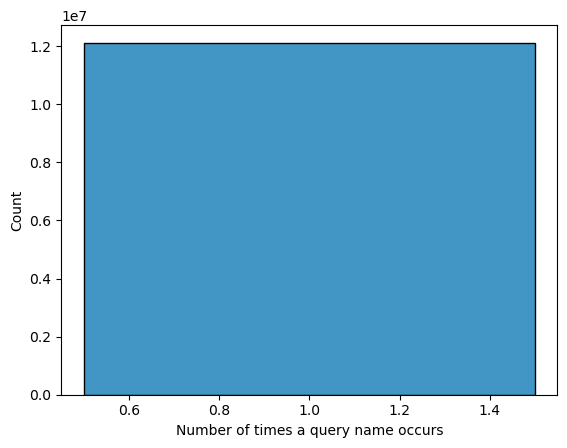

In [3]:
query_name_counts = df.query_name.value_counts()

sns.histplot(query_name_counts.values, discrete=True)
plt.xlabel("Number of times a query name occurs")
plt.show()


In [4]:
num_reads_per_file = df.groupby('file_name')['query_name'].nunique()

In [5]:
num_reads_per_file

file_name
m84223_251126_143521_s2.hifi_reads.bc2011.bam        6424942
m84223_251126_143521_s2.hifi_reads.bc2015.bam        5661978
m84223_251126_143521_s2.hifi_reads.unassigned.bam      30659
Name: query_name, dtype: int64

In [6]:
df_dropped = df.dropna(subset=['upstream_barcode', 'downstream_barcode'])
dropped_read_number = len(df) - len(df_dropped)
print(f'Dropped {dropped_read_number} ({100*dropped_read_number/len(df):.2f}%) reads with missing upstream or downstream barcode')
df_dropped

Dropped 6513505 (53.75%) reads with missing upstream or downstream barcode


,query_name,file_name,upstream_barcode,downstream_barcode,lib001_variable_exon,lib001_variable_intron,lib002_variable_exon,lib002_variable_intron,lib003_variable_exon,lib004_junction
0,m84223_251126_143521_s2/217779628/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,TTACTA,GGCTAGCTAACATCAGAGAG,GTTCTTCCTGCTGAGTTGTGTTCCATATCATCTTTGTCTTTACTTA...,TTGTAGCTATCATACTTCGTTGGCAGTTTGGACTGGGTGT,NaN,NaN,NaN,NaN
1,m84223_251126_143521_s2/210309522/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,GACATA,GACATAATTCCTGGGTTGAC,AGTTTATATTAATCGCATCTGGTTTTTAGATAGTGTGTGTCTTTAC...,CGGGTCGAAAGAAACTTTTTTTTATTATTAAAATAACGTC,NaN,NaN,NaN,NaN
25,m84223_251126_143521_s2/262803812/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,TCTCAA,ATTTAGGCCAAAATAATTT,ATTGTTCACTGGTAGCGAGCGCAGGGAAATGGCAAATAAATATACG...,TAGCGAGTCAGAATTAAAAACACTCGCAGACAGGTATGCA,NaN,NaN,NaN,NaN
26,m84223_251126_143521_s2/210376133/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,TTGCTG,TATCACGACCTGATGGCAAA,GTAAATATCTCTCAGTTTTCTGAGTTGTGTTGGTATATTCATGGTT...,CATTAAGACAGGACATGAAATGGGTATTATTAATCCTGCA,NaN,NaN,NaN,NaN
27,m84223_251126_143521_s2/209064413/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,TTCACT,AGGTGATACTGAGTTGTGTG,TTTAGACTGGATTATTCGTCTTCTTCTTTTTCATGAAAAATCGGTA...,CTAACGCAGCGCTTCTTGTTTGTATAACTATTTACTTGCC,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
12115292,m84223_251126_143521_s2/159585455/ccs,m84223_251126_143521_s2.hifi_reads.unassigned.bam,TTTGA,CCGCTTGGACCATTTAATGT,NaN,NaN,TAATTTTTACCTGCATTATGGCTTTTAGATTATCTGTTGAAATATG...,TACTCTGTATTAGTCTTGATCGAGCTCGCAACAGACCTTA,NaN,NaN
12115293,m84223_251126_143521_s2/213456372/ccs,m84223_251126_143521_s2.hifi_reads.unassigned.bam,GGTGTG,ACTTCCTTATGTCACGCCCA,NaN,NaN,CATAGATATTGATTTAGTAATTAGGTAAATCAAACGCCACACATCC...,AATGGGATGTACCTCTTGCAGTTAGGGCTCTGACCCCTCT,NaN,NaN
12115294,m84223_251126_143521_s2/132844770/ccs,m84223_251126_143521_s2.hifi_reads.unassigned.bam,CGCTAC,CAAGAGACCAGAAACCAAAT,NaN,NaN,ATGTCTTACCTGCCAGTTTCCCCGGTCCTCCGTTTTATGTAGCTCA...,ATGAATCGAGTGTGGCATGCAGTAAGCATCCGCTTCCTCA,NaN,NaN
12115296,m84223_251126_143521_s2/167055889/ccs,m84223_251126_143521_s2.hifi_reads.unassigned.bam,TGTGAT,GTTCTCGATTTGATAACCTG,NaN,NaN,TTTTATTTGCCAAATTTCAGAGTTCGTTTTTTGCCAAGACAAATTA...,AAGTCAGTTCATTCTATTCGCTCGATAAGAACTGTATACT,NaN,NaN


In [8]:
no_bc_df = df[df['upstream_barcode'].isna() | df['downstream_barcode'].isna()]
no_bc_df

,query_name,file_name,upstream_barcode,downstream_barcode,lib001_variable_exon,lib001_variable_intron,lib002_variable_exon,lib002_variable_intron,lib003_variable_exon,lib004_junction
2,m84223_251126_143521_s2/234820256/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,m84223_251126_143521_s2/249957577/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,m84223_251126_143521_s2/259592903/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,m84223_251126_143521_s2/215026891/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,m84223_251126_143521_s2/221779807/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
12117574,m84223_251126_143521_s2/197597117/ccs,m84223_251126_143521_s2.hifi_reads.unassigned.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12117575,m84223_251126_143521_s2/218894526/ccs,m84223_251126_143521_s2.hifi_reads.unassigned.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12117576,m84223_251126_143521_s2/140907889/ccs,m84223_251126_143521_s2.hifi_reads.unassigned.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12117577,m84223_251126_143521_s2/192090172/ccs,m84223_251126_143521_s2.hifi_reads.unassigned.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
files = no_bc_df.file_name.unique()
files

array(['m84223_251126_143521_s2.hifi_reads.bc2011.bam',
       'm84223_251126_143521_s2.hifi_reads.bc2015.bam',
       'm84223_251126_143521_s2.hifi_reads.unassigned.bam'], dtype=object)

In [13]:
with open("./output/parse_v4/no_bc_reads.txt", 'w') as f:
    for qname in no_bc_df.query_name:
        f.write(f"{qname}\n")

In [14]:
print('grabbing reads with no barcodes from bc2011')
! samtools view --fast -h -N ./output/parse_v4/no_bc_reads.txt -o ./output/parse_v4/no_bc_reads_bc2011.bam ../hifi_reads/m84223_251126_143521_s2.hifi_reads.bc2011.bam
print('grabbing reads with no barcodes from bc2015')
! samtools view --fast -h -N ./output/parse_v4/no_bc_reads.txt -o ./output/parse_v4/no_bc_reads_bc2015.bam ../hifi_reads/m84223_251126_143521_s2.hifi_reads.bc2015.bam

print('grabbing reads with no barcodes from unassigned')
! samtools view --fast -h -N ./output/parse_v4/no_bc_reads.txt -o ./output/parse_v4/no_bc_reads_unassigned.bam ../hifi_reads/m84223_251126_143521_s2.hifi_reads.unassigned.bam

grabbing reads with no barcodes from bc2011
grabbing reads with no barcodes from bc2015
[E::bgzf_flush] File write failed (wrong size)
samtools view: writing to "./output/parse_v4/no_bc_reads_bc2015.bam" failed: Disk quota exceeded
samtools view: error reading file "../hifi_reads/m84223_251126_143521_s2.hifi_reads.bc2015.bam": Disk quota exceeded
[E::bgzf_close] File write failed
samtools view: error closing "./output/parse_v4/no_bc_reads_bc2015.bam": -1
grabbing reads with no barcodes from unassigned
[E::bgzf_flush] File write failed (wrong size)
samtools view: writing to "./output/parse_v4/no_bc_reads_unassigned.bam" failed: Disk quota exceeded
samtools view: error reading file "../hifi_reads/m84223_251126_143521_s2.hifi_reads.unassigned.bam": Disk quota exceeded
[E::bgzf_close] File write failed
samtools view: error closing "./output/parse_v4/no_bc_reads_unassigned.bam": -1


In [16]:
import pysam

bam_files = [
    "./output/parse_v4/no_bc_reads_bc2011.bam",
    # "./output/parse_v4/no_bc_reads_bc2015.bam",
    # "./output/parse_v4/no_bc_reads_unassigned.bam"
]

fasta_files = [
    "./output/parse_v4/no_bc_reads_bc2011.first20.fasta",
    # "./output/parse_v4/no_bc_reads_bc2015.first20.fasta",
    # "./output/parse_v4/no_bc_reads_unassigned.first20.fasta"
]

for bam_file, fasta_file in zip(bam_files, fasta_files):
    with pysam.AlignmentFile(bam_file, "rb", check_sq=False) as bam, open(fasta_file, "w") as fasta:
        for i, read in enumerate(bam):
            if i >= 20:
                break
            seq_id = read.query_name
            seq = read.query_sequence
            # skip if missing sequence for some reason
            if seq is None:
                continue
            fasta.write(f">{seq_id}\n{seq}\n")


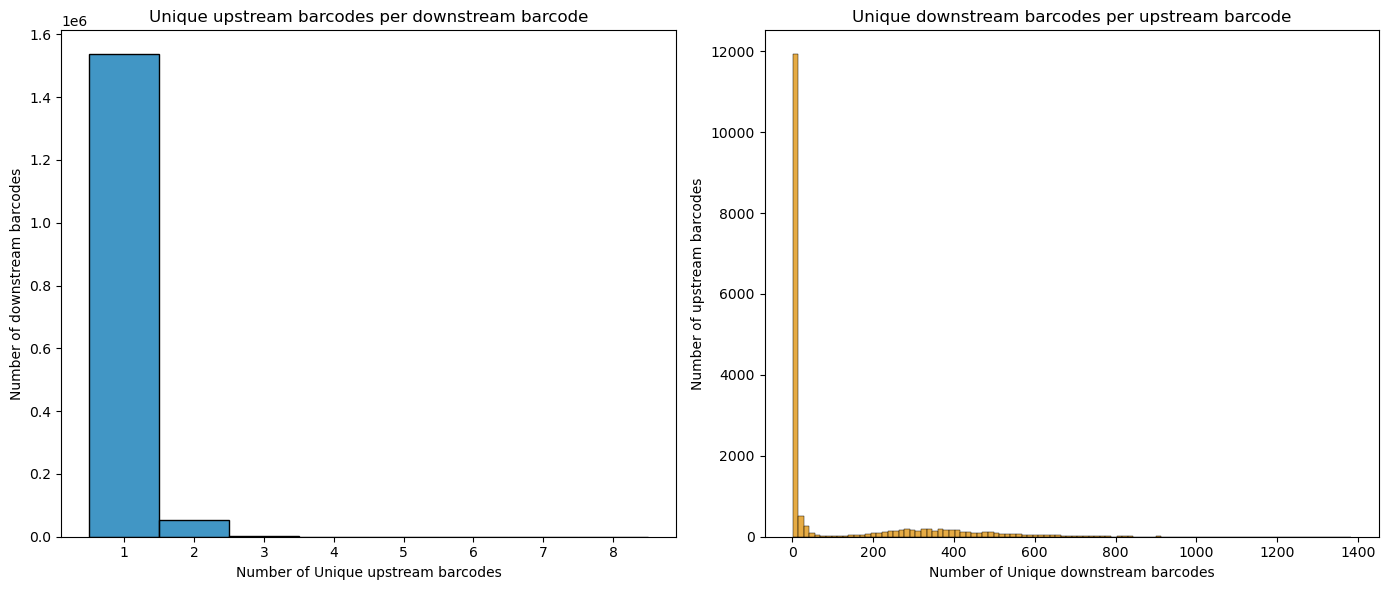

In [7]:
# Calculate number of unique variable regions per barcode
unique_downstream_barcodes_per_upstream_barcode = (
    df_dropped.groupby('upstream_barcode')['downstream_barcode'].nunique()
)

# Calculate number of unique barcodes per variable region
unique_upstream_barcodes_per_downstream_barcode = (
    df_dropped.groupby('downstream_barcode')['upstream_barcode'].nunique()
)

plt.figure(figsize=(14, 6))

# Histogram: Unique variable exons per barcode
plt.subplot(1, 2, 1)
sns.histplot(unique_upstream_barcodes_per_downstream_barcode, discrete=True, color='C0')
plt.title("Unique upstream barcodes per downstream barcode")
plt.xlabel("Number of Unique upstream barcodes")
plt.ylabel("Number of downstream barcodes")

# Histogram: Unique barcodes per variable exon
plt.subplot(1, 2, 2)
sns.histplot(unique_downstream_barcodes_per_upstream_barcode, bins=100, color='C1')
plt.title("Unique downstream barcodes per upstream barcode")
plt.xlabel("Number of Unique downstream barcodes")
plt.ylabel("Number of upstream barcodes")

plt.tight_layout()
plt.show()


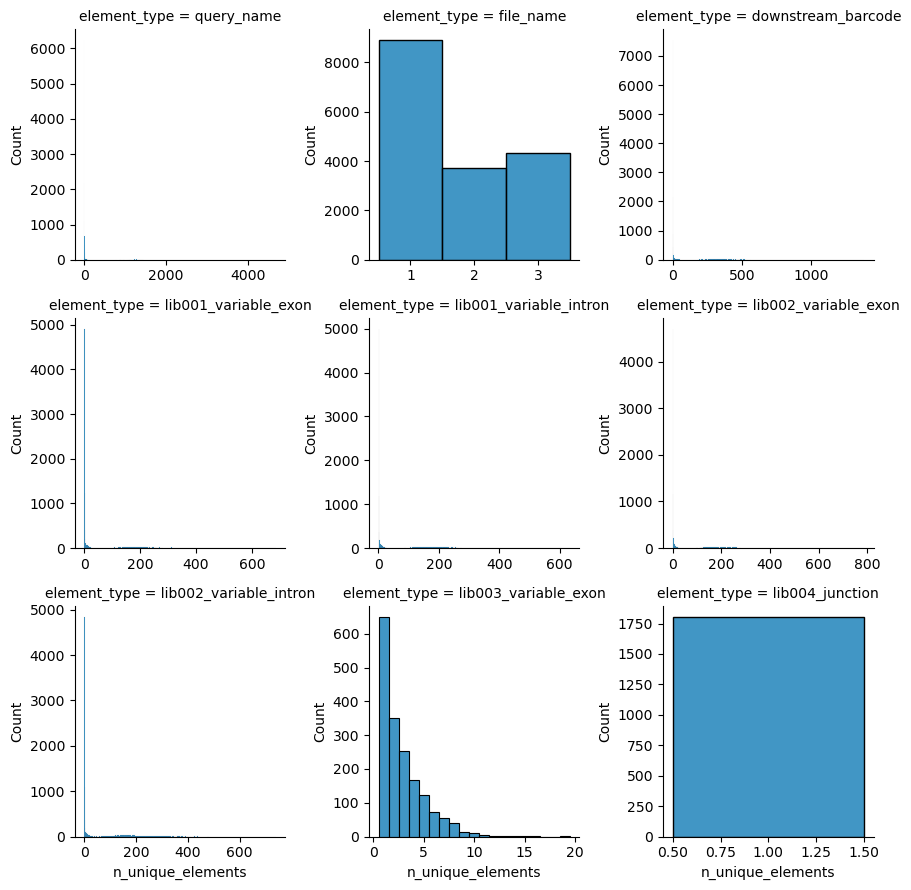

In [11]:
unique_elements_per_upstream_barcode = df_dropped.groupby('upstream_barcode').nunique().replace(0, np.nan)

unique_elements_per_upstream_barcode = unique_elements_per_upstream_barcode.reset_index().melt(var_name='element_type', value_name='n_unique_elements', id_vars='upstream_barcode')

f = sns.FacetGrid(unique_elements_per_upstream_barcode, col='element_type', col_wrap=3, sharex=False, sharey=False)
f.map_dataframe(sns.histplot, x='n_unique_elements', discrete=True, color='C0')
plt.show()





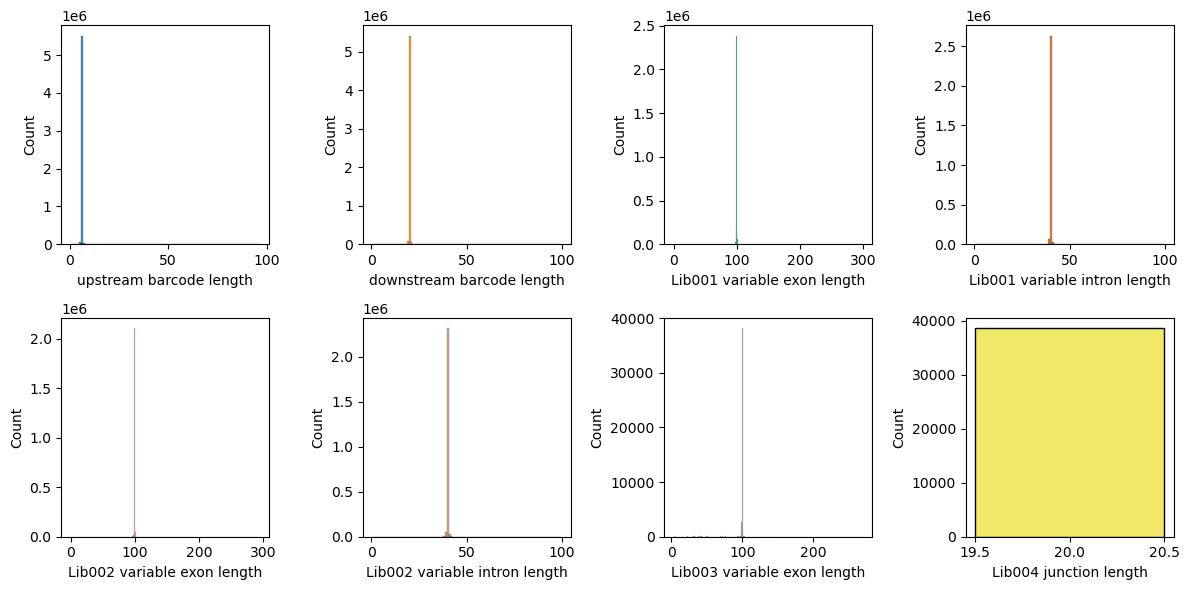

In [70]:
# Compute lengths
upstream_barcode_lengths = df_dropped['upstream_barcode'].str.len()
downstream_barcode_lengths = df_dropped['downstream_barcode'].str.len()
lib001_variable_exon_lengths = df_dropped.dropna(subset=['lib001_variable_exon'])['lib001_variable_exon'].str.len()
lib001_variable_intron_lengths = df_dropped.dropna(subset=['lib001_variable_intron'])['lib001_variable_intron'].str.len()
lib002_variable_exon_lengths = df_dropped.dropna(subset=['lib002_variable_exon'])['lib002_variable_exon'].str.len()
lib002_variable_intron_lengths = df_dropped.dropna(subset=['lib002_variable_intron'])['lib002_variable_intron'].str.len()
lib003_variable_exon_lengths = df_dropped.dropna(subset=['lib003_variable_exon'])['lib003_variable_exon'].str.len()
lib004_junction_lengths = df_dropped.dropna(subset=['lib004_junction'])['lib004_junction'].str.len()

plt.figure(figsize=(12, 6))

plt.subplot(2, 4, 1)
sns.histplot(upstream_barcode_lengths, discrete=True, color='C0')
plt.xlabel("upstream barcode length")
plt.ylabel("Count")

plt.subplot(2, 4, 2)
sns.histplot(downstream_barcode_lengths, discrete=True, color='C1')
plt.xlabel("downstream barcode length")
plt.ylabel("Count")

plt.subplot(2, 4, 3)
sns.histplot(lib001_variable_exon_lengths, discrete=True, color='C2')
plt.xlabel("Lib001 variable exon length")
plt.ylabel("Count")

plt.subplot(2, 4, 4)
sns.histplot(lib001_variable_intron_lengths, discrete=True, color='C3')
plt.xlabel("Lib001 variable intron length")
plt.ylabel("Count")

plt.subplot(2, 4, 5)
sns.histplot(lib002_variable_exon_lengths, discrete=True, color='C4')
plt.xlabel("Lib002 variable exon length")
plt.ylabel("Count")

plt.subplot(2, 4, 6)
sns.histplot(lib002_variable_intron_lengths, discrete=True, color='C5')
plt.xlabel("Lib002 variable intron length")
plt.ylabel("Count")

plt.subplot(2, 4, 7)
sns.histplot(lib003_variable_exon_lengths, discrete=True, color='C7')
plt.xlabel("Lib003 variable exon length")
plt.ylabel("Count")

plt.subplot(2, 4, 8)
sns.histplot(lib004_junction_lengths, discrete=True, color='C8')
plt.xlabel("Lib004 junction length")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


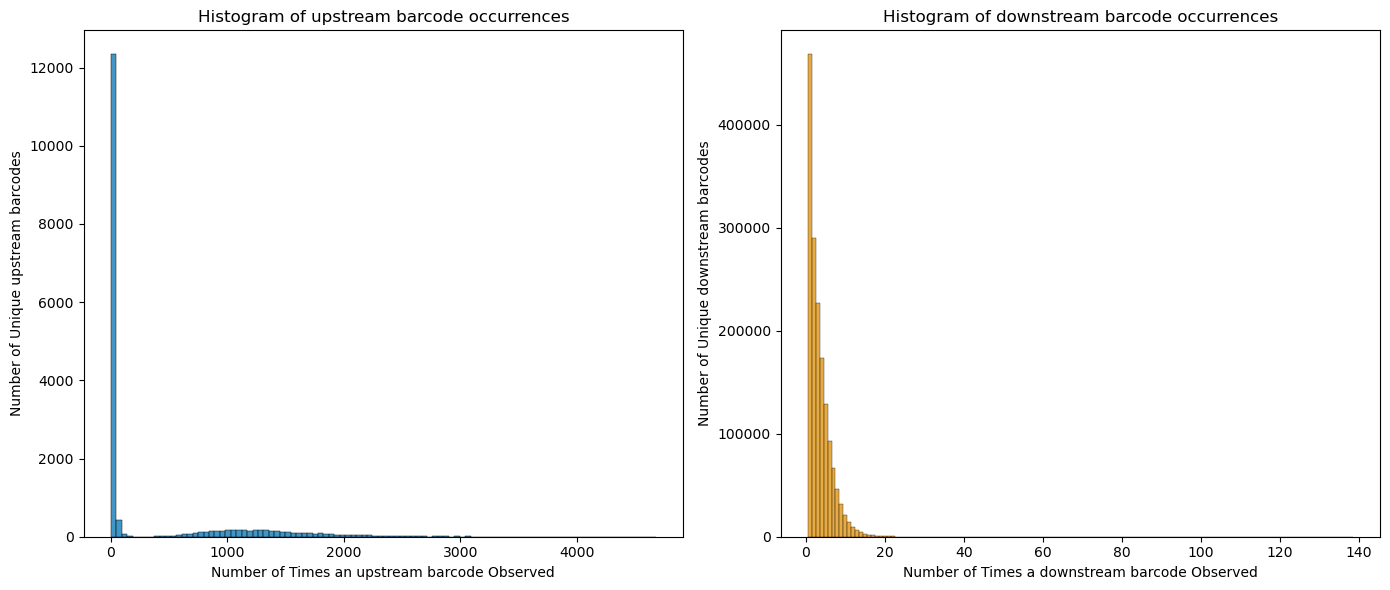

In [42]:
# Count frequency of each unique barcode and variable_exon
upstream_barcode_counts = df_dropped['upstream_barcode'].value_counts()
downstream_barcode_counts = df_dropped['downstream_barcode'].value_counts()

plt.figure(figsize=(14, 6))

# Histogram for barcode frequencies
plt.subplot(1, 2, 1)
sns.histplot(upstream_barcode_counts.values, bins=100, color='C0')
plt.title("Histogram of upstream barcode occurrences")
plt.xlabel("Number of Times an upstream barcode Observed")
plt.ylabel("Number of Unique upstream barcodes")

# Histogram for variable_exon frequencies
plt.subplot(1, 2, 2)
sns.histplot(downstream_barcode_counts.values, discrete=True, color='C1')
plt.title("Histogram of downstream barcode occurrences")
plt.xlabel("Number of Times a downstream barcode Observed")
plt.ylabel("Number of Unique downstream barcodes")

plt.tight_layout()
plt.show()


/tmp/ipykernel_366795/200544186.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dropped['library_assignment'] = 'None'
/tmp/ipykernel_366795/200544186.py:10: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.barplot(x=library_counts.index, y=library_counts.values, hue=library_counts.index, palette=sns.color_palette('colorblind')[2:], edgecolor='black')


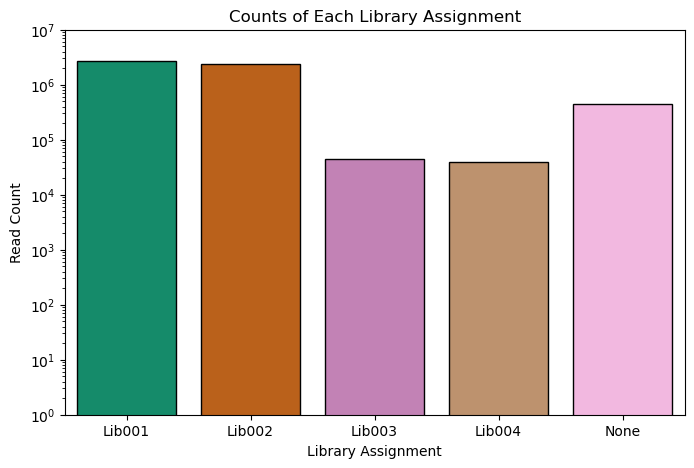

unassigned reads: 449182 (8.02%)


In [43]:
df_dropped['library_assignment'] = 'None'
df_dropped.loc[df_dropped['lib001_variable_exon'].notna() & df_dropped['lib001_variable_intron'].notna() ,'library_assignment'] = 'Lib001'
df_dropped.loc[df_dropped['lib002_variable_exon'].notna() & df_dropped['lib002_variable_intron'].notna() ,'library_assignment'] = 'Lib002'
df_dropped.loc[df_dropped['lib003_variable_exon'].notna() ,'library_assignment'] = 'Lib003'
df_dropped.loc[df_dropped['lib004_junction'].notna() ,'library_assignment'] = 'Lib004'

# Barplot of the counts of each library_assignment
library_counts = df_dropped['library_assignment'].value_counts().sort_index()
plt.figure(figsize=(8,5))
sns.barplot(x=library_counts.index, y=library_counts.values, hue=library_counts.index, palette=sns.color_palette('colorblind')[2:], edgecolor='black')
plt.title("Counts of Each Library Assignment")
plt.xlabel("Library Assignment")
plt.ylabel("Read Count")
plt.yscale('log')
plt.ylim(1, 1e7)
plt.show()

print(f"unassigned reads: {library_counts.loc['None']} ({100*library_counts.loc['None']/library_counts.sum():.2f}%)")

/tmp/ipykernel_366795/2763757161.py:4: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.barplot(data=library_counts, x='library_assignment', y='barcode_count', hue='library_assignment', palette=sns.color_palette('colorblind')[2:], edgecolor='black')


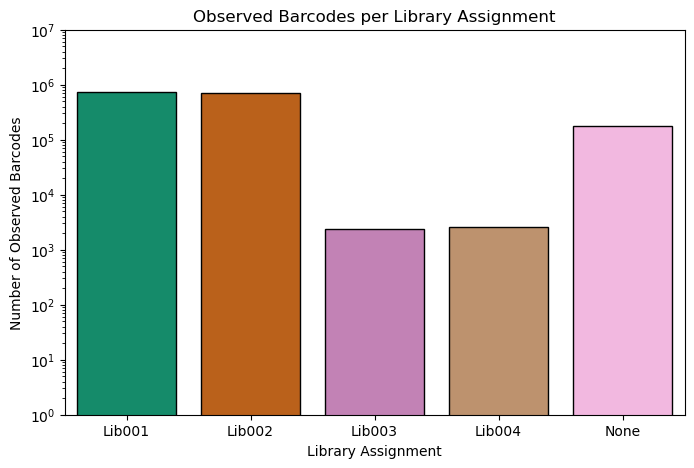

/tmp/ipykernel_366795/2763757161.py:16: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.barplot(data=library_counts, x='library_assignment', y='barcode_count_seen_3x', hue='library_assignment', palette=sns.color_palette('colorblind')[2:], edgecolor='black')


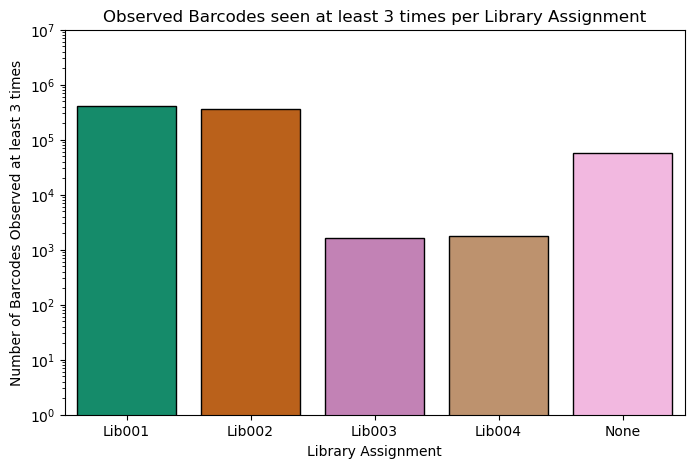

In [68]:
# Barplot of the counts of each library_assignment
library_counts = df_dropped.groupby('library_assignment')['downstream_barcode'].nunique().reset_index(name='barcode_count')
plt.figure(figsize=(8,5))
sns.barplot(data=library_counts, x='library_assignment', y='barcode_count', hue='library_assignment', palette=sns.color_palette('colorblind')[2:], edgecolor='black')
plt.title("Observed Barcodes per Library Assignment")
plt.xlabel("Library Assignment")
plt.ylabel("Number of Observed Barcodes")
plt.yscale('log')
plt.ylim(1, 1e7)
plt.show()

library_counts = df_dropped.groupby(['library_assignment','downstream_barcode'])['query_name'].agg(['count']).reset_index()
library_counts = library_counts[library_counts['count'] >= 3]
library_counts = library_counts.groupby('library_assignment')['downstream_barcode'].nunique().reset_index(name='barcode_count_seen_3x')
plt.figure(figsize=(8,5))
sns.barplot(data=library_counts, x='library_assignment', y='barcode_count_seen_3x', hue='library_assignment', palette=sns.color_palette('colorblind')[2:], edgecolor='black')
plt.title("Observed Barcodes seen at least 3 times per Library Assignment")
plt.xlabel("Library Assignment")
plt.ylabel("Number of Barcodes Observed at least 3 times")
plt.yscale('log')
plt.ylim(1, 1e7)
plt.show()

In [67]:
library_counts = df_dropped.groupby(['library_assignment','downstream_barcode'])['query_name'].agg(['count']).reset_index()
library_counts = library_counts[library_counts['count'] >= 3]
library_counts = library_counts.groupby('library_assignment')['downstream_barcode'].nunique().reset_index(name='barcode_count_seen_3x')
library_counts

,library_assignment,barcode_count_seen_3x
0,Lib001,404657
1,Lib002,361154
2,Lib003,1634
3,Lib004,1786
4,None,56637


In [58]:
library_counts

,library_assignment,barcode_count
0,Lib001,751685
1,Lib002,716539
2,Lib003,2401
3,Lib004,2557
4,None,174960


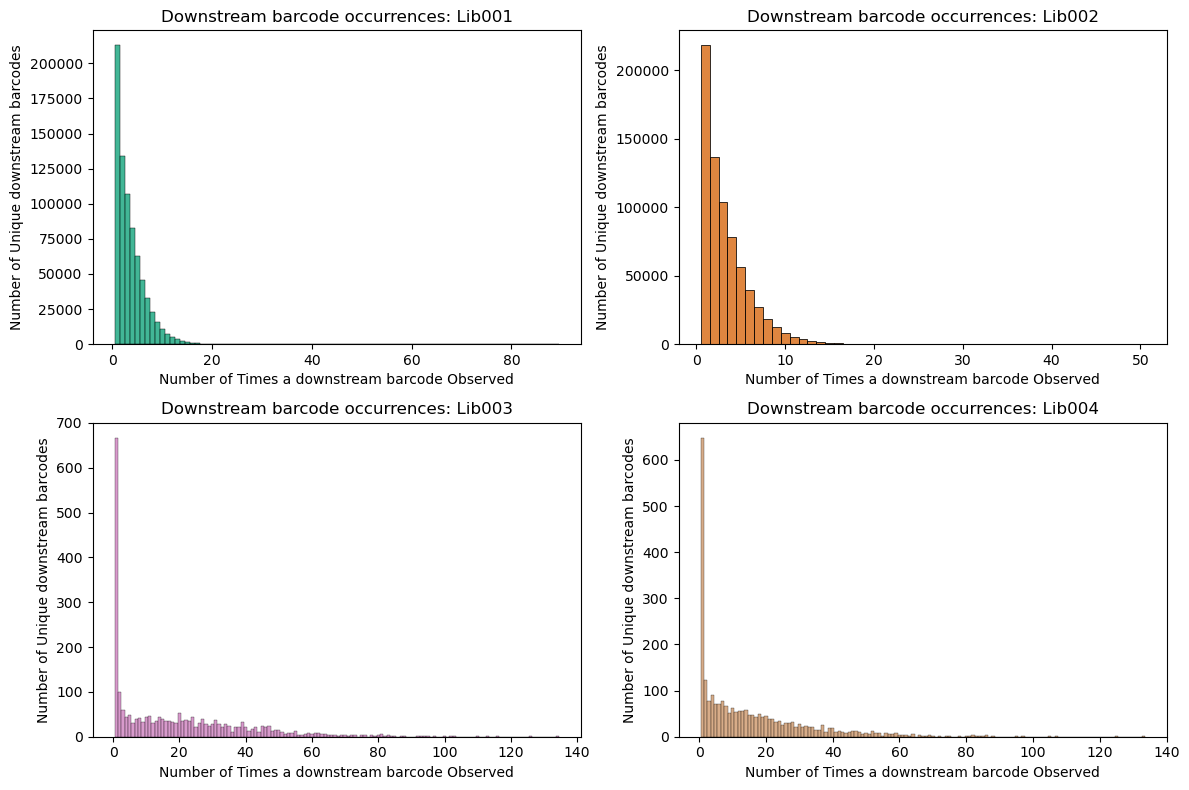

In [44]:
# Prepare data for each library assignment
assignments = ['Lib001', 'Lib002', 'Lib003', 'Lib004']
ncols = 2
nrows = 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, lib in enumerate(assignments):
    ax = axes[idx]
    sub_df = df_dropped[df_dropped['library_assignment'] == lib]
    downstream_counts = sub_df['downstream_barcode'].value_counts()
    sns.histplot(downstream_counts.values,
                 discrete=True, 
                 color='C'+str(idx+2), 
                 ax=ax)
    ax.set_title(f"Downstream barcode occurrences: {lib}")
    ax.set_xlabel("Number of Times a downstream barcode Observed")
    ax.set_ylabel("Number of Unique downstream barcodes")

for j in range(len(assignments), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


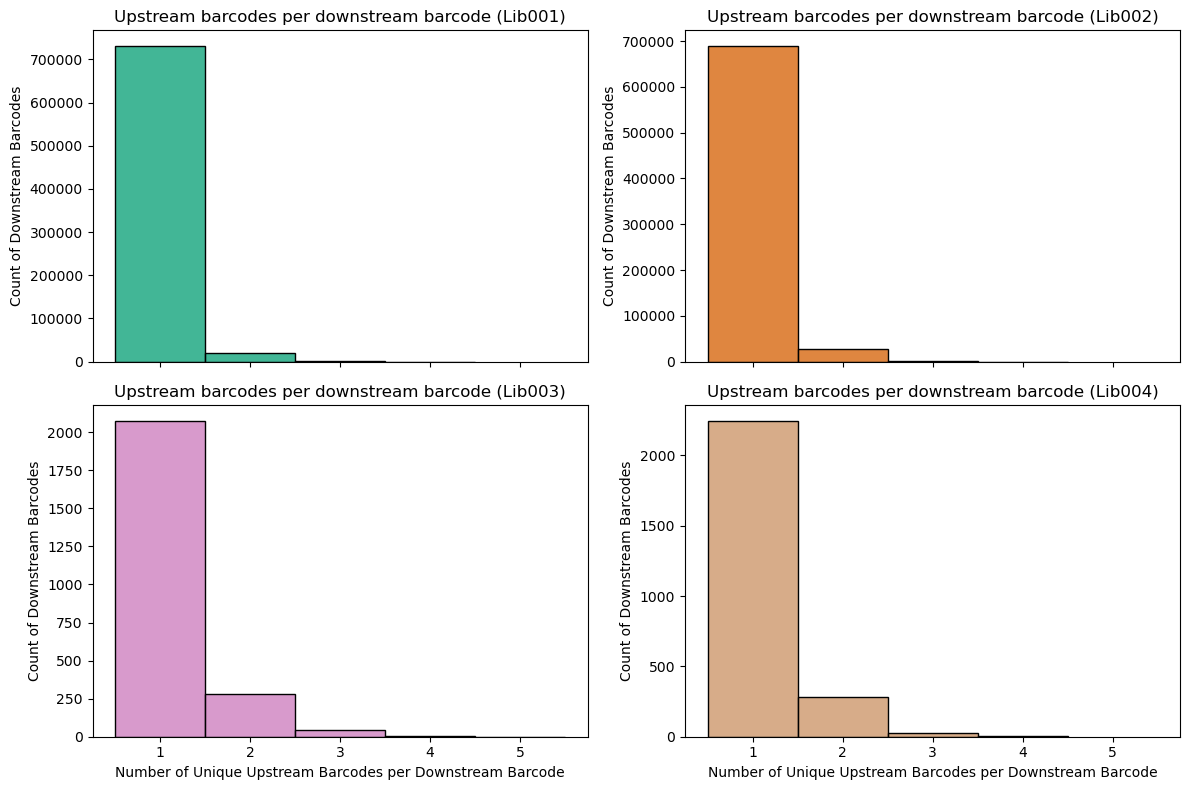

In [45]:
# Plot the number of unique upstream barcodes per downstream barcode, split by library assignment

assignments = ['Lib001', 'Lib002', 'Lib003', 'Lib004']
ncols = 2
nrows = 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 8), sharex=True, sharey=False)
axes = axes.flatten()

for idx, lib in enumerate(assignments):
    ax = axes[idx]
    sub_df = df_dropped[df_dropped['library_assignment'] == lib]

    # Count unique upstream barcodes (columns 'upstream_barcode', 'downstream_barcode')
    per_down_bc = (
        sub_df
        .groupby('downstream_barcode')['upstream_barcode']
        .nunique()
    )
    sns.histplot(per_down_bc.values, 
                 bins=30, 
                 discrete=True,
                 color='C'+str(idx+2), 
                 ax=ax)
    ax.set_title(f"Upstream barcodes per downstream barcode ({lib})")
    ax.set_xlabel("Number of Unique Upstream Barcodes per Downstream Barcode")
    ax.set_ylabel("Count of Downstream Barcodes")

for j in range(len(assignments), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


/tmp/ipykernel_366795/3370007756.py:15: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  g = sns.catplot(


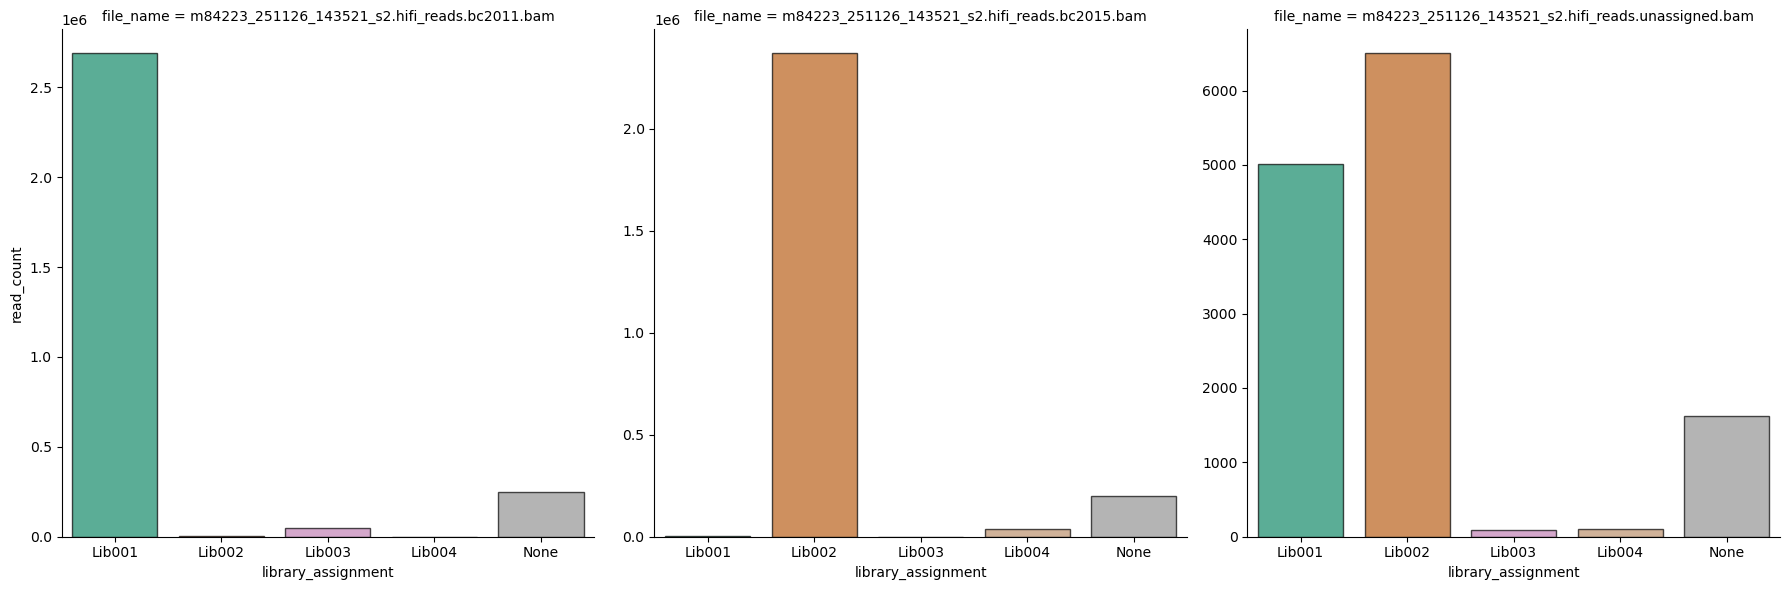

In [55]:
# Plot library counts by file_name

# Prepare count data
from os import altsep


library_counts_long = (
    df_dropped
    .groupby(['file_name', 'library_assignment'])['query_name']
    .count()
    .reset_index(name='read_count')
)


g = sns.catplot(
    data=library_counts_long,
    x='library_assignment',
    y='read_count',
    col='file_name',
    col_wrap=3,
    kind='bar',
    sharey=False,
    height=6,
    aspect=1,
    hue='library_assignment',
    palette=np.array(sns.color_palette('colorblind'))[[2,3,4,5,7]],
    edgecolor='black',
    alpha=0.7,
    # log_scale=True
)

plt.show()


In [17]:
df_dropped.groupby('downstream_barcode')['upstream_barcode'].nunique()

downstream_barcode
A                        2
AAA                      3
AAAAAAAAAAAAAATGTAATC    1
AAAAAAAAAAAAAGTTACTAC    1
AAAAAAAAAAAAATGTAATC     1
                        ..
TTTTTTTTTTCACGAGAGAG     1
TTTTTTTTTTCCATAGGCAC     1
TTTTTTTTTTCCCTGAAGGA     1
TTTTTTTTTTGCTGGACCTC     1
TTTTTTTTTTTCCCTGAAGGA    1
Name: upstream_barcode, Length: 1591759, dtype: int64